In [1]:
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
pd.pandas.set_option('display.max_columns',None)
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from scipy.stats import probplot, boxcox

In [2]:
rating = pd.read_csv('BX-Book-Ratings.csv', encoding='latin-1', on_bad_lines='warn',sep=';')
book = pd.read_csv('BX-Books.csv', encoding='latin-1', on_bad_lines='warn',sep=';')

/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/4083424723.py:2: ParserWarning: Skipping line 6452: expected 8 fields, saw 9
Skipping line 43667: expected 8 fields, saw 10
Skipping line 51751: expected 8 fields, saw 9

  book = pd.read_csv('BX-Books.csv', encoding='latin-1', on_bad_lines='warn',sep=';')
/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/4083424723.py:2: ParserWarning: Skipping line 92038: expected 8 fields, saw 9
Skipping line 104319: expected 8 fields, saw 9
Skipping line 121768: expected 8 fields, saw 9

  book = pd.read_csv('BX-Books.csv', encoding='latin-1', on_bad_lines='warn',sep=';')
/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/4083424723.py:2: ParserWarning: Skipping line 144058: expected 8 fields, saw 9
Skipping line 150789: expected 8 fields, saw 9
Skipping line 157128: expected 8 fields, saw 9
Skipping line 180189: expected 8 fields, saw 9
Skipping line 185738: expected 8 fields, saw 9

  book = pd.read_csv('BX

In [3]:
book.head(2)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...


In [4]:
rating.head(2)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5


In [6]:
print("Books:",book.shape)
print("Ratings:",rating.shape)

Books: (271360, 8)


NameError: name 'user' is not defined

In [7]:
book.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [8]:

book = book[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-L']]

In [9]:
book[book['Book-Author'].isnull()]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...


In [10]:
book.at[128890, 'Publisher'] = 'Mundania Press'
book.at[129037, 'Publisher'] = 'NovelBooks, Incorporated'

In [11]:
book[book['Image-URL-L'].isnull()]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,NaN


In [12]:
book.at[209538, 'Book-Title'] ='Creating the X-Men, How Comic Books Come to Life (Level 4)'
book.at[209538, 'Book-Author'] = 'James Buckley,Michael Teitelbaum'
book.at[209538, 'Year-Of-Publication'] = '2000'
book.at[209538, 'Publisher'] = 'DK Publishing Inc'
book.at[209538, 'Image-URL-L'] = 'http://images.amazon.com/images/P/0789466953.01.THUMBZZZ.jpg'

In [13]:
book[book['ISBN']=='078946697X'].values.tolist()

[['078946697X',
  'Creating the X-Men, How Comic Books Come to Life (Level 4)',
  'James Buckley,Michael Teitelbaum',
  '2000',
  'DK Publishing Inc',
  'http://images.amazon.com/images/P/0789466953.01.THUMBZZZ.jpg']]

In [14]:
book.at[220731, 'Book-Title'] ='Peuple du ciel, suivi de'
book.at[220731, 'Book-Author'] = 'Jean-Marie Gustave Le Clézio'
book.at[220731, 'Year-Of-Publication'] = '2003'
book.at[220731, 'Publisher'] = 'Gallimard'
book.at[220731, 'Image-URL-L'] = 'http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg'

In [15]:
book.at[3543, 'Year-Of-Publication']=1986

In [16]:
book[book['ISBN']=='2070426769'].values.tolist()

[['2070426769',
  'Peuple du ciel, suivi de',
  'Jean-Marie Gustave Le Clézio',
  '2003',
  'Gallimard',
  'http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg']]

In [17]:
book = book.drop(index=221678)
book = book.drop(index=118033)

In [18]:
book.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            1
Year-Of-Publication    0
Publisher              0
Image-URL-L            0
dtype: int64

In [19]:
book.shape

(271358, 6)

In [20]:
book['Book-Author'].value_counts().head(15)

Book-Author
Agatha Christie         632
William Shakespeare     567
Stephen King            524
Ann M. Martin           423
Carolyn Keene           373
Francine Pascal         372
Isaac Asimov            330
Nora Roberts            315
Barbara Cartland        307
Charles Dickens         302
Not Applicable (Na )    286
R. L. Stine             282
Mark Twain              231
Jane Austen             223
Terry Pratchett         220
Name: count, dtype: int64

In [21]:
book[book['Book-Author'].str.contains(r'>', regex=True, na=False)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
15404,2070567842,Folio Junior: L'histoire De Monsieur Sommer,Su>skind-Sempe,0,Gallimard-Jeunesse,http://images.amazon.com/images/P/2070567842.0...
52778,3423705000,DTV Junior: Emil Und Die Detektive,Ka>stner,0,Deutscher Taschenbuch Verlag (DTV),http://images.amazon.com/images/P/3423705000.0...


In [22]:
book.at[52778, 'Book-Author']='Erich Kästner'
book.at[52778, 'Year-Of-Publication']=1991

In [23]:
book[book['Book-Author'].str.contains(r'@', regex=True, na=False)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
163148,1580080707,Cybercafes: A Worldwide Guide for Travelers,cyberkath@traveltales.com,1999,Ten Speed Press,http://images.amazon.com/images/P/1580080707.0...


In [24]:
book.at[163148, 'Book-Author']

In [25]:
book[book['Book-Author'].str.match(r'^[a-zA-Z]{2}$', na=False)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
28171,0395556376,Fate: New Poems,Ai,1991,Houghton Mifflin,http://images.amazon.com/images/P/0395556376.0...
75343,0380018853,Complete Runner,Ed,1983,Avon Books,http://images.amazon.com/images/P/0380018853.0...
104544,0060977612,God Is My Broker: A Monk-Tycoon Reveals the 7 ...,Ty,1999,Perennial,http://images.amazon.com/images/P/0060977612.0...
108819,0786834617,"Annette Mysteries, The - Box Set of 4 (Walt Di...",tk,2003,Disney Press,http://images.amazon.com/images/P/0786834617.0...
116382,0888888880,The Circle,Na,1999,Not Avail,http://images.amazon.com/images/P/0888888880.0...
123695,0786845848,The Lizzie McGuire Movie: Jr. Novel,tk,2003,Disney Press,http://images.amazon.com/images/P/0786845848.0...
130250,0590541781,Little Theme (My First Library),Na,1995,Scholastic,http://images.amazon.com/images/P/0590541781.0...
154042,0889627657,Wild Things Live Here: The Best of Northern Fr...,Na,2002,Mosaic Press,http://images.amazon.com/images/P/0889627657.0...
159340,3499430916,"Blut Will Der Damon (Fiction, Poetry and Drama)",Ky,0,Rowohlt Taschenbuch Verlag GmbH,http://images.amazon.com/images/P/3499430916.0...
166826,349920360X,HeiÃ?Â?t du wirklich Hassan Schmidt? Ein Krimi...,ky,1997,Rowohlt Tb.,http://images.amazon.com/images/P/349920360X.0...


In [26]:

book.at[28171, 'Book-Author']='Al Ogawa'
book.at[75343, 'Book-Author']="Runner's World Magazine"
book.at[104544, 'Book-Author']='Christopher Buckley and John Tierney'
book.at[108819	, 'Book-Title'] ="The Annette Mysteries collectionsr"
book.at[108819	, 'Book-Author'] ="Doris Schroeder"
book.at[123695	, 'Book-Author'] ="david cody weiss"
book.at[154042, 'Book-Author']='Don Hutchison'
book.at[159340, 'Book-Author']='Horst Bosetzky'
book.at[159340, 'Year-Of-Publication']=1993

book.at[166826, 'Book-Author']='Horst Bosetzky'
book.at[166826, 'Book-Title']="Heißt du wirklich Hasan Schmidt?"
book.at[191218, 'Book-Author']='Better Homes and Gardens'
book.at[191218, 'Book-Title']="Better Homes and Gardens New Cook Book"
book = book.drop(197735)
book = book.drop(203968)
book.at[219235, 'Year-Of-Publication']=1989
book.at[243506	, 'Book-Title'] ="Walt Disney's Santa's Toy Shop"
book.at[243506	, 'Book-Author'] ="Al Dempster"
book.at[256126, 'Book-Author']="Paul Fleming, Volker Meid"

book.at[261900, 'Book-Author']='Better Homes and Gardens'
book.at[261900, 'Book-Title']="Crockery Cooking (Better Homes and Gardens)"
book.at[263394, 'Book-Author']='Better Homes and Gardens'

In [27]:

book[book['Book-Author']=='x x']

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
149212,1591050367,An American Redneck in Hong Kong,x x,2002,"NovelBooks, Inc.",http://images.amazon.com/images/P/1591050367.0...
207132,1931696837,Unlawful,x x,2002,"NovelBooks, Inc.",http://images.amazon.com/images/P/1931696837.0...
212941,1591050804,Winter Fire,x x,2002,"NovelBooks, Inc.",http://images.amazon.com/images/P/1591050804.0...
234548,1931696810,Mating Season,x x,2002,"NovelBooks, Inc.",http://images.amazon.com/images/P/1931696810.0...


In [28]:
book.at[149212	, 'Book-Author'] ="Michael LaRocca"
book.at[207132	, 'Book-Author'] ="Dorice Nelson"
book.at[212941	, 'Book-Author'] ="Kathy Fischer-Brown"
book.at[234548	, 'Book-Author'] ="Liz Hunter"

In [29]:
book[book['Book-Author']=='unknown']

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
96703,1561449164,Pound It (Popular Mechanics for Kids),unknown,1997,Modern Publishing,http://images.amazon.com/images/P/1561449164.0...
267861,0960638822,A Course In Miracles Workbook for students Man...,unknown,1985,Foundation For Inner Peace,http://images.amazon.com/images/P/0960638822.0...


In [ ]:
book.at[267861	, 'Book-Title'] ='A Course In Miracles Workbook for students Manual for Teachers'
book.at[267861	, 'Book-Author'] ="Helen Schucman"
book = book.drop(96703)

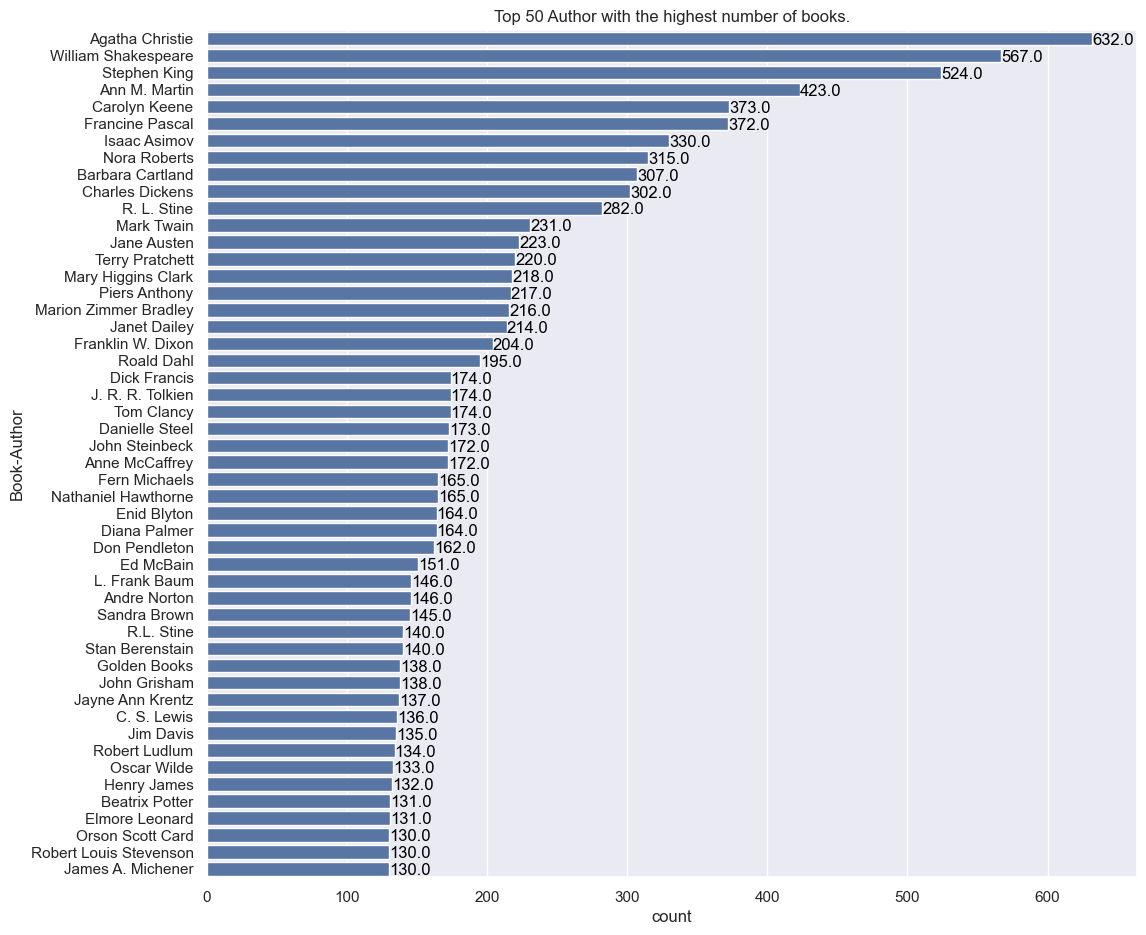

In [30]:
top_authors = book[book['Book-Author'] != 'Not Applicable (Na )']['Book-Author'].value_counts().head(50).index

sns.set(style='darkgrid')
plt.figure(figsize=(12,11))

book['Publisher'].value_counts().head(20)
ax = sns.countplot(y='Book-Author', data=book[book['Book-Author'].isin(top_authors)], order=top_authors)


for i in ax.patches:
    ax.text(i.get_width() + 0.05, i.get_y() + 0.5, f'{i.get_width():.1f}', 
            fontsize=12, color='black', va='center')

plt.title('Top 50 Author with the highest number of books.')
plt.show()

In [31]:
book['Publisher'].value_counts().head(20)

Publisher
Harlequin                   7535
Silhouette                  4220
Pocket                      3905
Ballantine Books            3783
Bantam Books                3646
Scholastic                  3160
Simon &amp; Schuster        2971
Penguin Books               2844
Berkley Publishing Group    2771
Warner Books                2727
Penguin USA                 2717
Harpercollins               2525
Fawcett Books               2258
Signet Book                 2070
Random House Inc            2045
St Martins Pr               1953
St. Martin's Press          1783
Tor Books                   1704
HarperCollins Publishers    1700
Zebra Books                 1694
Name: count, dtype: int64

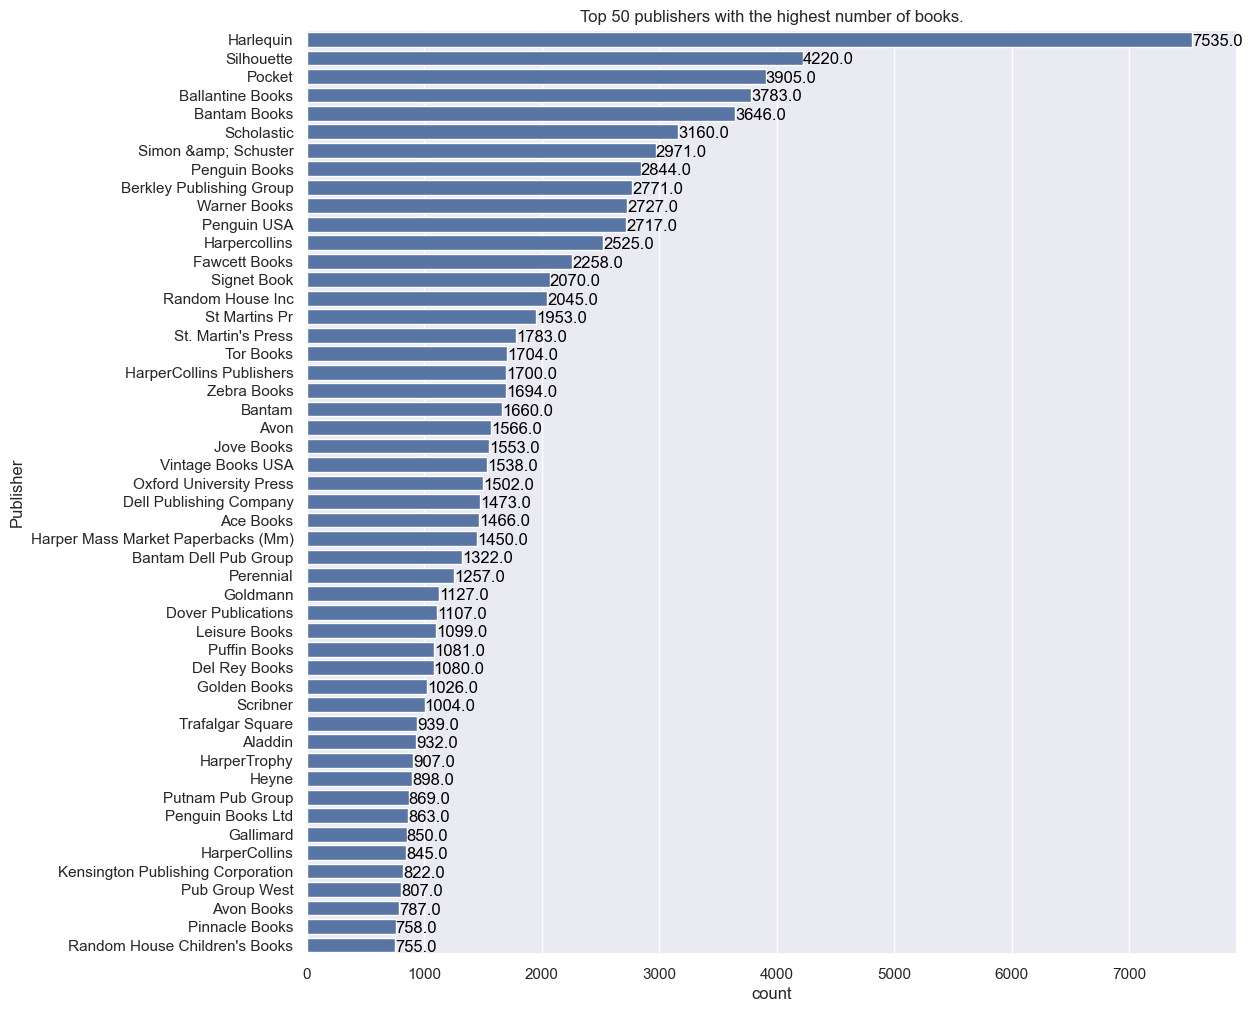

In [32]:
top_Publisher=book['Publisher'].value_counts().head(50).index

sns.set(style='darkgrid')
plt.figure(figsize=(12,12))

ax = sns.countplot(y='Publisher', data=book[book['Publisher'].isin(top_Publisher)], order=top_Publisher)


for i in ax.patches:
    ax.text(i.get_width() + 0.05, i.get_y() + 0.5, f'{i.get_width():.1f}', 
            fontsize=12, color='black', va='center')

plt.title('Top 50 publishers with the highest number of books.')
plt.show()

In [33]:
book['Year-Of-Publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

In [34]:
book = book.copy()
book['Year-Of-Publication']=book['Year-Of-Publication'].astype('int64')

In [35]:
book['Year-Of-Publication'].value_counts().sort_index(ascending=False).head(10)

Year-Of-Publication
2050    2
2038    1
2037    1
2030    7
2026    1
2024    1
2021    1
2020    3
2012    1
2011    2
Name: count, dtype: int64

In [36]:
book['Year-Of-Publication'].value_counts().sort_index(ascending=True).head(10)

Year-Of-Publication
0       4614
1376       1
1378       1
1806       1
1897       1
1900       3
1901       7
1902       2
1904       1
1906       1
Name: count, dtype: int64

In [37]:
book[book['Year-Of-Publication']>2010][['ISBN','Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
12782,0380816792,A Rose in Winter,Kathleen E. Woodiwiss,2011,Harper Mass Market Paperbacks
30010,068160204X,The Royals,Kitty Kelley,2020,Bausch &amp; Lombard
37487,0671746103,MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEA...,Coville,2030,Aladdin
55676,0671791990,MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY ...,Bruce Coville,2030,Aladdin
78168,0870449842,Crossing America,National Geographic Society,2030,National Geographic
80264,0140301690,Alice's Adventures in Wonderland and Through t...,Lewis Carroll,2050,Puffin Books
92156,068107468X,Edgar Allen Poe Collected Poems,Edgar Allan Poe,2020,Bausch &amp; Lombard
97826,0140201092,Outline of European Architecture (Pelican S.),Nikolaus Pevsner,2050,Penguin USA
116053,0394701658,Three Plays of Eugene Oneill,Eugene O'Neill,2038,Vintage Books USA
118294,3442436893,Das groÃ?Â?e BÃ?Â¶se- MÃ?Â¤dchen- Lesebuch.,Kathy Lette,2026,Goldmann


In [38]:

book.at[240169, 'Year-Of-Publication'] =1958

book.at[246842, 'Year-Of-Publication'] =1995

book.at[235425, 'Year-Of-Publication'] =1943

book.at[260974, 'Year-Of-Publication'] =1991

book.at[255409, 'Year-Of-Publication'] =1991
book.at[255409, 'Publisher'] ="Charles Scribner's Sons"

book.at[97826, 'Year-Of-Publication'] =1990
	
book.at[199196, 'Year-Of-Publication'] =1983
book.at[199196, 'Book-Author'] ='Laima Dingwall'
book.at[199196, 'Publisher'] ="Western Publishing Company"

book.at[228173, 'Year-Of-Publication'] =1987
book.at[228173, 'Book-Title'] ='The Forest People'
book.at[228173, 'Publisher'] ="Touchstone"

book.at[192993, 'Year-Of-Publication'] =1999

book.at[118294, 'Year-Of-Publication'] =2006
book.at[118294, 'Book-Title'] ='Das große Böse- Mädchen- Lesebuch'

book.at[116053, 'Year-Of-Publication'] =1995
book.at[116053, 'Publisher'] ="Vintage Books"

book.at[80264, 'Year-Of-Publication'] =2003
book.at[80264, 'Publisher'] ="Penguin Books"

book.at[78168, 'Year-Of-Publication'] =1999

book.at[55676, 'Year-Of-Publication'] =1992

book.at[30010, 'Year-Of-Publication'] =1998
book.at[30010, 'Publisher'] ="Hachette Book Group USA"

book.at[37487, 'Year-Of-Publication'] =1991
book.at[37487, 'Book-Author'] =' Bruce Coville'

book.at[92156, 'Year-Of-Publication'] =2013
book.at[92156, 'Book-Title'] ='The Poems of Edgar Allan Poe'
book.at[92156, 'Publisher'] ="Courier Corporation"

In [39]:
book[(book['Year-Of-Publication']<1900)&(book['Year-Of-Publication']>0)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
171817,0781228956,"Complete Works 10 Volumes [2,6,7,8,9] (Notable...",Benjamin Franklin,1806,Reprint Services Corp,http://images.amazon.com/images/P/0781228956.0...
227531,9643112136,Dalan-i bihisht (Dastan-i Irani),Nazi Safavi,1378,Intisharat-i Quqnus,http://images.amazon.com/images/P/9643112136.0...
245607,0781268001,"Hugh Wynne, Free Quaker (2 Volumes (BCL1-PS Am...",Silas Weir Mitchell,1897,Reprint Services Corp,http://images.amazon.com/images/P/0781268001.0...
253750,964442011X,Tasht-i khun,IsmaÂ°il Fasih,1376,Nashr-i Alburz,http://images.amazon.com/images/P/964442011X.0...


In [40]:
book.at[227531	, 'Year-Of-Publication'] =2010

/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/1606218324.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


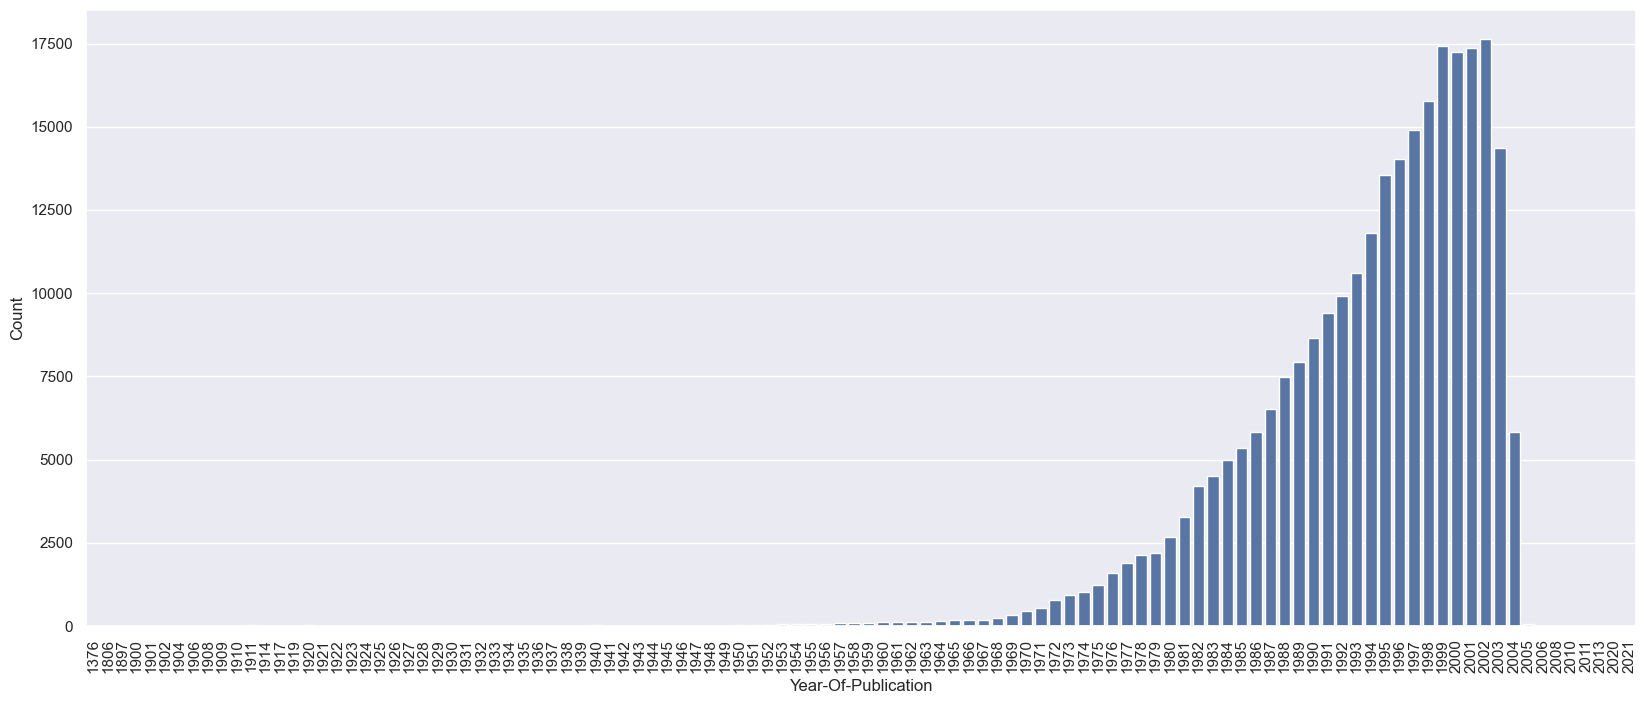

In [41]:
year_counts =  book[book['Year-Of-Publication'] != 0]['Year-Of-Publication'].value_counts().reset_index()
year_counts.columns = ['Year-Of-Publication', 'Count'] 

year_counts = year_counts.sort_values('Year-Of-Publication')

sns.set(rc={'figure.figsize':(20,8)})

ax = sns.barplot(x=year_counts['Year-Of-Publication'], y=year_counts['Count'])

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.show()

In [42]:
filter_ratings = rating[rating['ISBN'].isin(book['ISBN'])]
filter_ratings

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149774,276704,0876044011,0
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10


In [43]:
bookrating = pd.merge(filter_ratings, book, on="ISBN")
bookrating.head(2)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...


In [44]:
bookrating.shape

(1031132, 8)

In [45]:
book_rating = bookrating.groupby('Book-Title')['Book-Rating'].idxmax()
book_rating = bookrating.loc[book_rating]
book_rating.head(2)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
358379,96448,0590567330,9,A Light in the Storm: The Civil War Diary of ...,Karen Hesse,1999,Hyperion Books for Children,http://images.amazon.com/images/P/0590567330.0...
638646,172742,0964147726,0,Always Have Popsicles,Rebecca Harvin,1994,Rebecca L. Harvin,http://images.amazon.com/images/P/0964147726.0...


In [46]:
book_rating.shape

(241065, 8)

In [47]:
avg_rating =  book_rating.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_rating.rename(columns={'Book-Rating':'Average-Rating'}, inplace=True)
avg_rating.head()

,Book-Title,Average-Rating
0,A Light in the Storm: The Civil War Diary of ...,9.0
1,Always Have Popsicles,0.0
2,Apple Magic (The Collector's series),0.0
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.0
4,Beyond IBM: Leadership Marketing and Finance ...,0.0


In [48]:
avgbook_ratings = pd.merge(book_rating, avg_rating, on='Book-Title')
avgbook_ratings.head(2)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L,Average-Rating
0,96448,0590567330,9,A Light in the Storm: The Civil War Diary of ...,Karen Hesse,1999,Hyperion Books for Children,http://images.amazon.com/images/P/0590567330.0...,9.0
1,172742,0964147726,0,Always Have Popsicles,Rebecca Harvin,1994,Rebecca L. Harvin,http://images.amazon.com/images/P/0964147726.0...,0.0


In [49]:
avgbook_ratings['Average-Rating'].value_counts().sort_index(ascending=False)

Average-Rating
10.0     39310
9.0      22135
8.0      28220
7.0      18580
6.0       8595
5.0      14532
4.0       1936
3.0       1249
2.0        597
1.0        410
0.0     105501
Name: count, dtype: int64

In [50]:
num_rating = bookrating.groupby('Book-Title')['Book-Rating'].count().reset_index()
num_rating.rename(columns={'Book-Rating':'Number-of-Rating'}, inplace=True)
num_rating

,Book-Title,Number-of-Rating
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241060,Ã?Â?lpiraten.,2
241061,Ã?Â?rger mit Produkt X. Roman.,4
241062,Ã?Â?sterlich leben.,1
241063,Ã?Â?stlich der Berge.,3


In [51]:

numb_ratings = pd.merge(avgbook_ratings, num_rating, on='Book-Title')
numb_ratings.head(2)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L,Average-Rating,Number-of-Rating
0,96448,0590567330,9,A Light in the Storm: The Civil War Diary of ...,Karen Hesse,1999,Hyperion Books for Children,http://images.amazon.com/images/P/0590567330.0...,9.0,4
1,172742,0964147726,0,Always Have Popsicles,Rebecca Harvin,1994,Rebecca L. Harvin,http://images.amazon.com/images/P/0964147726.0...,0.0,1


In [52]:
threshold = numb_ratings['Number-of-Rating'].quantile(0.90)
top_10_percent = numb_ratings[numb_ratings['Number-of-Rating'] >= threshold]

In [53]:
top_10_percent[(top_10_percent['Number-of-Rating'] >800)].sort_values(by='Number-of-Rating', ascending=True)[['Book-Title', 'Number-of-Rating', 'Average-Rating']]

,Book-Title,Number-of-Rating,Average-Rating
27918,Bridget Jones's Diary,815,10.0
199230,The Nanny Diaries: A Novel,828,10.0
5303,A Painted House,838,10.0
183566,The Da Vinci Code,898,10.0
196319,The Lovely Bones: A Novel,1295,10.0
234945,Wild Animus,2502,10.0


In [54]:
top_ratings_not_votes = top_10_percent[(top_10_percent['Number-of-Rating'] <10) & (top_10_percent['Average-Rating'] == 10)].sort_values(by='Number-of-Rating', ascending=True)[['Book-Title', 'Number-of-Rating', 'Average-Rating']]
top_ratings_not_votes.head(10)

,Book-Title,Number-of-Rating,Average-Rating
128544,Never Kissed Goodnight,7,10.0
87884,Hunger of Memory : The Education of Richard Ro...,7,10.0
178956,The Books in My Life,7,10.0
179055,The Box Garden,7,10.0
179290,"The Bride Fair (Harlequin Historical, No. 603)",7,10.0
86926,"How to Host a Seduction (Harlequin Blaze, No 80)",7,10.0
179485,"The Brothers of Gwynedd: Comprising, Sunrise i...",7,10.0
179835,The California Book of the Dead: A Novel,7,10.0
85999,Household Hints and Handy Tips,7,10.0
85930,House of Illusions,7,10.0


In [55]:
top_votes_not_ratings = top_10_percent[(top_10_percent['Number-of-Rating'] >=100) & (top_10_percent['Average-Rating'] == 9)].sort_values(by='Number-of-Rating', ascending=True)[['Book-Title', 'Number-of-Rating', 'Average-Rating']]
top_votes_not_ratings

,Book-Title,Number-of-Rating,Average-Rating
194912,The Laws of Our Fathers,110,9.0
47728,Degree of Guilt,116,9.0
43490,Dances With Wolves,127,9.0
195584,The Little Friend,139,9.0
1266,4 Blondes,151,9.0
122643,Moo,159,9.0


In [56]:
numb_ratings['Number-of-Rating'].value_counts()

Number-of-Rating
1      127507
2       42729
3       20254
4       11364
5        7530
        ...  
588         1
575         1
428         1
347         1
234         1
Name: count, Length: 377, dtype: int64

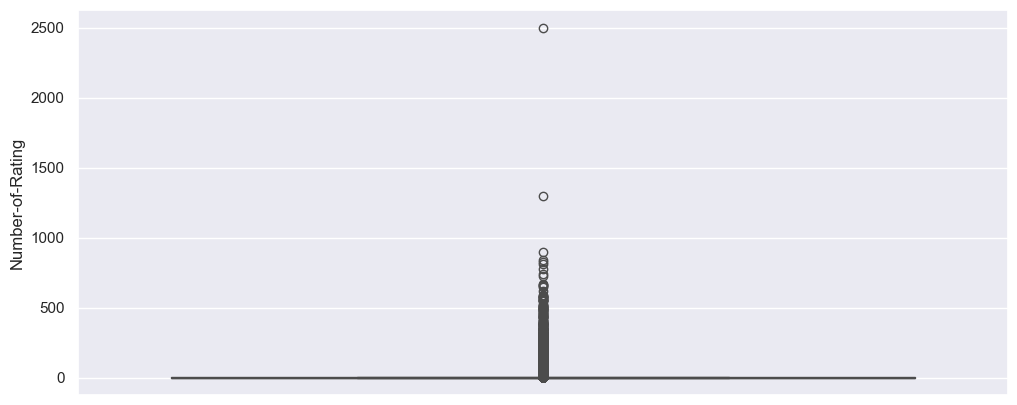

In [57]:
plt.figure(figsize=(12,5))
sns.boxplot(numb_ratings['Number-of-Rating'])
plt.show()

In [59]:
number_ratings=numb_ratings.copy()

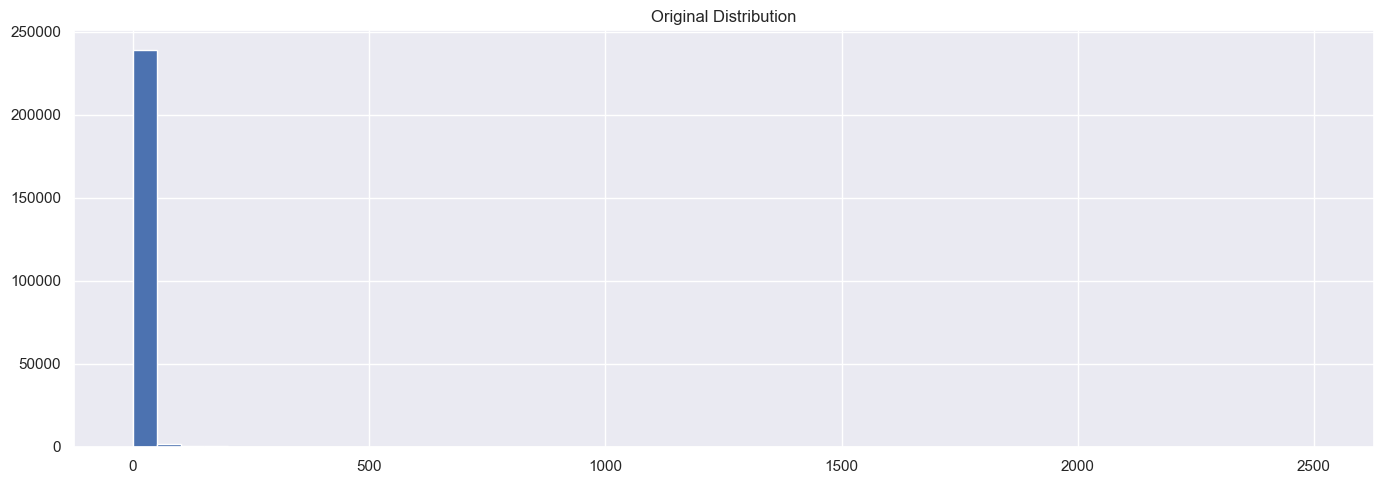

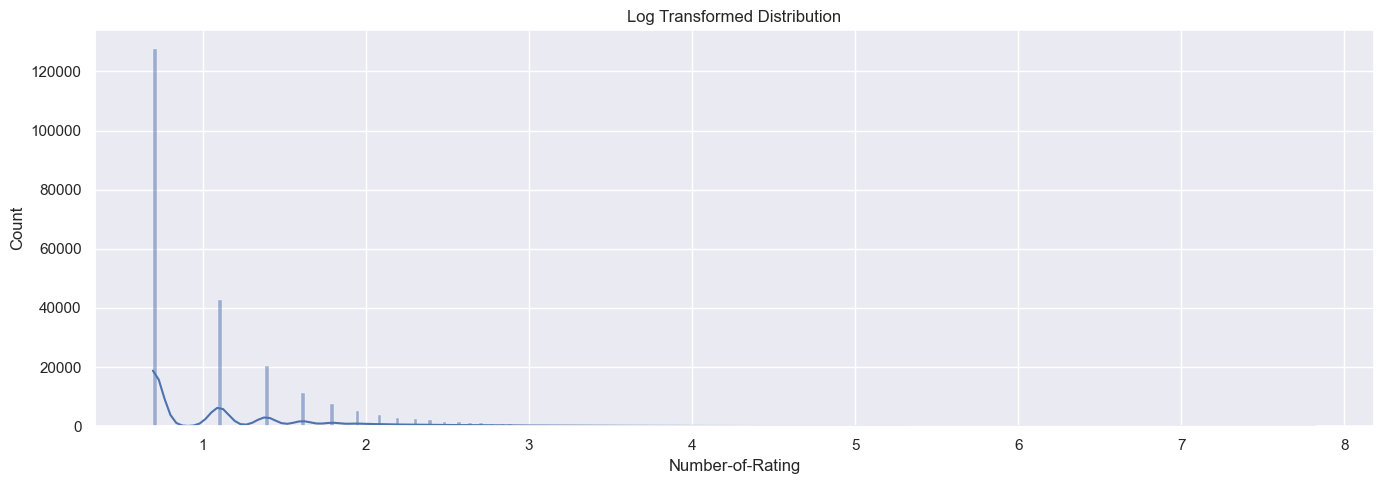

In [60]:
from scipy.stats import probplot, boxcox

plt.figure(figsize=(14, 5))
# Original Distribution and Q-Q Plot
plt.hist(numb_ratings['Number-of-Rating'], bins=50)
plt.title('Original Distribution')
plt.tight_layout()
plt.show()

# Log Transformation
number_ratings['Number-of-Rating'] = np.log1p(number_ratings['Number-of-Rating'])
plt.figure(figsize=(14, 5))
sns.histplot(number_ratings['Number-of-Rating'], kde=True)
plt.title('Log Transformed Distribution')
plt.tight_layout()
plt.show()

In [61]:
number_ratings = number_ratings[number_ratings['Number-of-Rating'] >= 1]
number_ratings['Number-of-Rating'] =number_ratings['Number-of-Rating'].astype(int)
number_ratings['Number-of-Rating'].value_counts()

Number-of-Rating
1    87174
2    18776
3     5389
4     1722
5      434
6       61
7        2
Name: count, dtype: int64

In [62]:
C = number_ratings['Average-Rating'].mean()


m = number_ratings['Number-of-Rating'].quantile(0.95)


def weighted_rating(row, C, m):
    v = row['Number-of-Rating'] 
    R = row['Average-Rating']     
    return ((R * v) + (C * m)) / (v + m)


number_ratings['Weighted-Rating'] = number_ratings.apply(weighted_rating, axis=1, C=C, m=m)

In [63]:
book_ratings_above_6 = number_ratings[number_ratings['Number-of-Rating'] >= 6]
book_ratings_above_6 = book_ratings_above_6[['User-ID', 'Book-Title', 'Average-Rating', 'Number-of-Rating', 'Weighted-Rating']]
book_ratings_above_6 = book_ratings_above_6.sort_values(by='Average-Rating', ascending=False)
book_ratings_above_6.head()

,User-ID,Book-Title,Average-Rating,Number-of-Rating,Weighted-Rating
818,278535,1st to Die: A Novel,10.0,6,8.680953
202237,22625,The Pilot's Wife : A Novel,10.0,6,8.680953
187695,383,The Firm,10.0,6,8.680953
187873,1848,The Five People You Meet in Heaven,10.0,6,8.680953
189259,7301,The Girls' Guide to Hunting and Fishing,10.0,6,8.680953


In [64]:
book_ratings_above_6.shape

(63, 5)

In [65]:
final_books=pd.merge(book_ratings_above_6,book, on='Book-Title').drop_duplicates('Book-Title',keep='first')
final_books.sort_values('Weighted-Rating', ascending=False).head(2)

,User-ID,Book-Title,Average-Rating,Number-of-Rating,Weighted-Rating,ISBN,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
267,12272,Wild Animus,10.0,7,8.812858,0971880107,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...
27,638,The Lovely Bones: A Novel,10.0,7,8.812858,0316666343,Alice Sebold,2002,"Little, Brown",http://images.amazon.com/images/P/0316666343.0...


/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/3661855388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Number-of-Rating', y='Book-Title', data=top_books, palette=color)
/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/3661855388.py:6: UserWarning: 
The palette list has fewer values (10) than needed (20) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x='Number-of-Rating', y='Book-Title', data=top_books, palette=color)


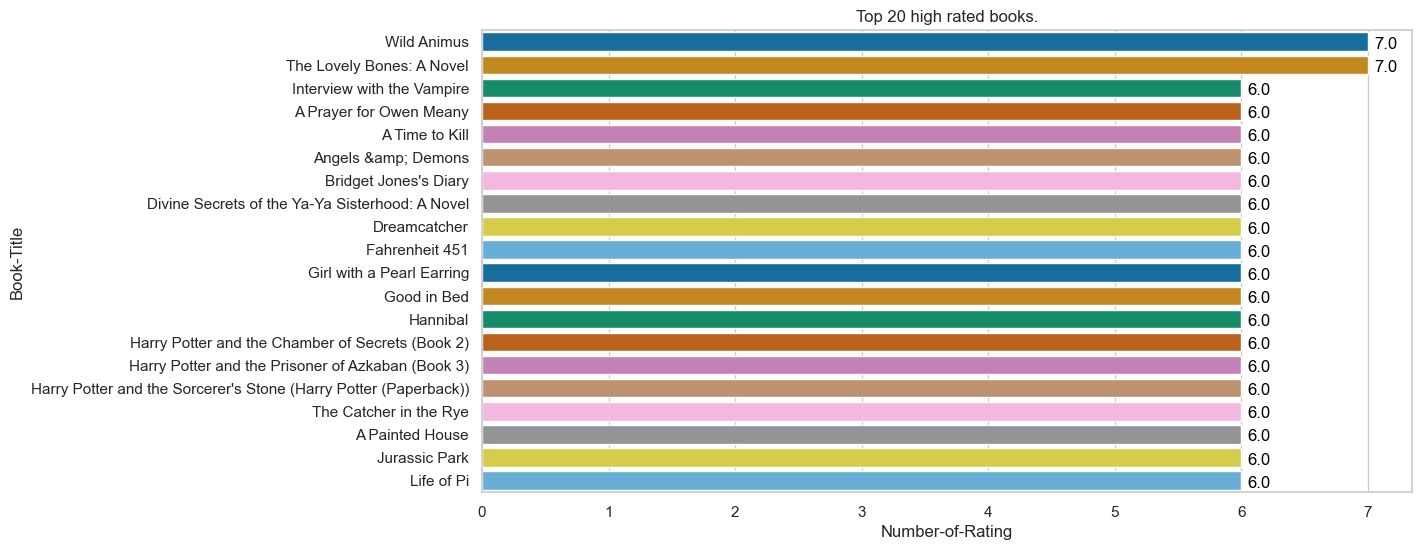

In [66]:
top_books = final_books.sort_values(by='Number-of-Rating', ascending=False).head(20)

sns.set(style='whitegrid')
plt.figure(figsize=(12,6))
color = sns.color_palette('colorblind')
ax = sns.barplot(x='Number-of-Rating', y='Book-Title', data=top_books, palette=color)

for i in ax.patches:
    ax.text(i.get_width() + 0.05, i.get_y() + 0.5, f'{i.get_width():.1f}', 
            fontsize=12, color='black', va='center')

plt.title('Top 20 high rated books.')
plt.show()

/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/2407436234.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Number-of-Rating', y='Book-Author', data=top_authors, palette=color)
/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/2407436234.py:7: UserWarning: 
The palette list has fewer values (10) than needed (20) and will cycle, which may produce an uninterpretable plot.
  ax=sns.barplot(x='Number-of-Rating', y='Book-Author', data=top_authors, palette=color)


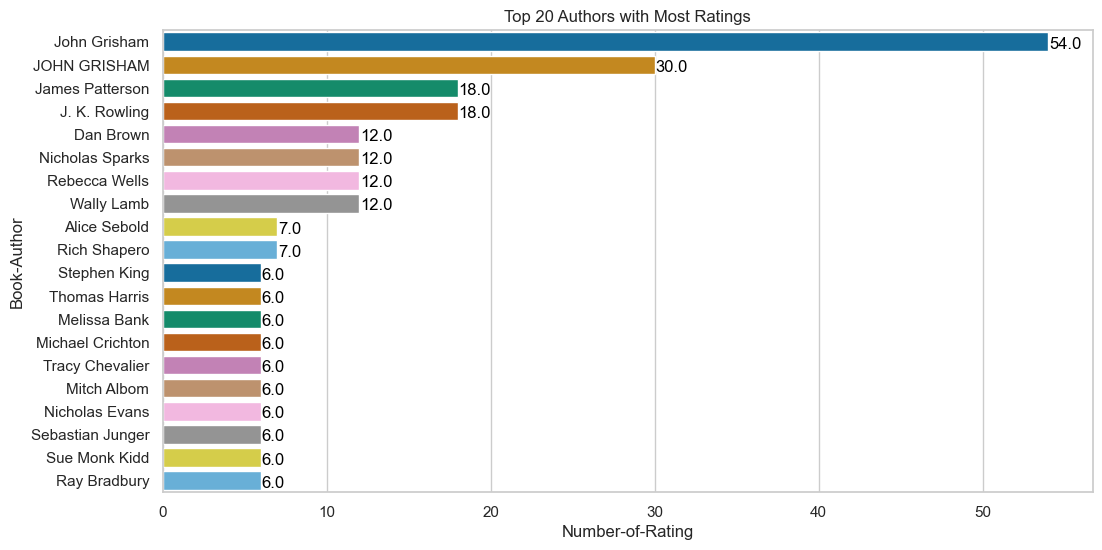

In [67]:
author_ratings = final_books.groupby('Book-Author')['Number-of-Rating'].sum().reset_index()
top_authors = author_ratings.sort_values(by='Number-of-Rating', ascending=False).head(20)

sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
color = sns.color_palette('colorblind')
ax=sns.barplot(x='Number-of-Rating', y='Book-Author', data=top_authors, palette=color)

for i in ax.patches:
    ax.text(i.get_width() + 0.05, i.get_y() + 0.5, f'{i.get_width():.1f}', 
            fontsize=12, color='black', va='center')

plt.title('Top 20 Authors with Most Ratings')
plt.show()

/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/1354729830.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Number-of-Rating', y='Publisher', data=top_authors, palette=color)
/var/folders/gx/d5rmrm6179b887zfb733hf8r0000gn/T/ipykernel_4109/1354729830.py:7: UserWarning: 
The palette list has fewer values (10) than needed (20) and will cycle, which may produce an uninterpretable plot.
  ax=sns.barplot(x='Number-of-Rating', y='Publisher', data=top_authors, palette=color)


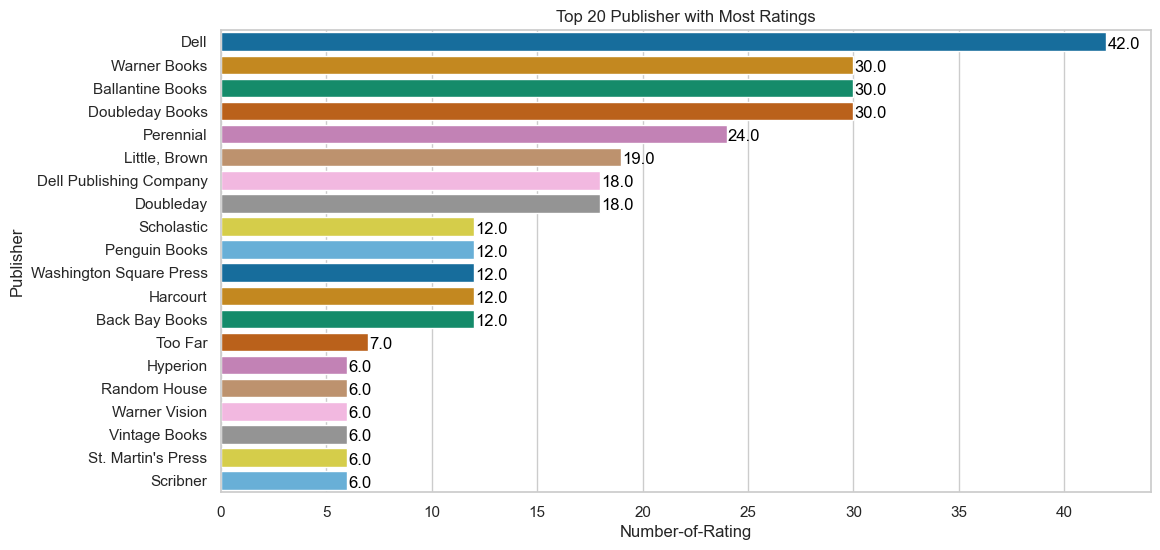

In [68]:
author_ratings = final_books.groupby('Publisher')['Number-of-Rating'].sum().reset_index()
top_authors = author_ratings.sort_values(by='Number-of-Rating', ascending=False).head(20)

sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
color = sns.color_palette('colorblind')
ax=sns.barplot(x='Number-of-Rating', y='Publisher', data=top_authors, palette=color)

for i in ax.patches:
    ax.text(i.get_width() + 0.05, i.get_y() + 0.5, f'{i.get_width():.1f}', 
            fontsize=12, color='black', va='center')

plt.title('Top 20 Publisher with Most Ratings')
plt.show()

In [69]:
it_based_book = number_ratings[number_ratings['Number-of-Rating'] >= 5]
it_based_book = it_based_book.sort_values(by='Average-Rating', ascending=False)
it_based_book.head(2)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L,Average-Rating,Number-of-Rating,Weighted-Rating
764,1706,0451524934,10,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,10.0,5,8.516072
178258,36907,0385720955,10,The Blind Assassin,Margaret Atwood,2001,Anchor Books/Doubleday,http://images.amazon.com/images/P/0385720955.0...,10.0,5,8.516072


In [70]:
it_based_book.shape

(497, 11)

In [71]:
book_pivot = it_based_book.pivot_table(index='Book-Title',columns='User-ID', values='Book-Rating')
book_pivot.fillna(0, inplace=True)
book_pivot.head()

User-ID,114,125,243,254,383,388,503,507,595,638,685,709,763,778,882,915,1021,1022,1032,1309,1427,1434,1435,1558,1608,1650,1674,1706,1733,1768,1848,1903,2010,2012,2030,2089,2139,2179,2276,2288,2439,2528,3166,3167,3305,3331,3363,3371,3373,3543,3556,3578,3596,3709,3827,4017,4365,4622,4795,4896,4938,4999,5034,5037,5048,5268,5385,5476,5499,5539,5582,5669,5850,6115,6135,6238,6251,6345,6368,6543,6563,6611,6637,6679,6789,6900,7079,7105,7155,7194,7248,7283,7301,7346,7841,7887,7915,8019,8067,8086,8089,8234,8253,8296,8454,8801,8839,8853,8935,8936,8937,9139,9314,9354,9605,9728,9747,9856,10153,10205,10269,10447,10643,11272,11400,11601,11676,12194,12272,12316,12589,12685,12707,12784,12926,13080,13432,13503,13551,13552,13709,13850,13907,14422,14454,14521,14546,15369,15408,15602,15651,16106,16246,16504,16718,16736,16795,16916,17003,17190,17402,17523,17859,18096,18908,19085,19107,19259,19573,19664,19760,20060,20172,20180,20254,20916,21031,21188,21191,21357,21370,21618,21895,22045,22495,22625,22936,23020,23511,23680,23871,23902,24009,24162,24926,24960,25062,25129,25395,25409,25583,25981,26192,26406,26593,27204,27617,28177,28619,28634,29526,29821,30081,30245,30735,30939,31116,31315,31391,31826,31980,32101,32154,32244,32250,32516,33319,34526,35842,35931,36907,37208,37227,37377,38023,38356,38950,39227,40012,40318,40732,40889,41013,41111,41117,43359,45078,47316,48494,49460,49761,50895,51207,51350,51450,51545,52159,53220,53414,54429,57095,57105,57959,58672,61917,63993,64665,69232,74056,75591,76151,83287,88229,88693,89091,91113,91491,93179,107616,113270,114368,117251,117384,131290,136561,140424,163358,165345,179791,184632,196821,215948,276788,276822,276896,276925,276953,277051,277179,277195,277235,277246,277427,277462,277523,277527,277722,277911,277922,277959,277965,277984,278122,278162,278333,278356,278487,278535,278550,278582,278633,278663,278698,278807,278832
Book-Title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [73]:
from sklearn.metrics.pairwise import cosine_similarity


cosine_sim = cosine_similarity(book_pivot)


cosine_sim_df = pd.DataFrame(cosine_sim, index=book_pivot.index, columns=book_pivot.index)

In [74]:
cosine_sim_df

Book-Title,1984,1st to Die: A Novel,2nd Chance,4 Blondes,A Bend in the Road,A Case of Need,"A Child Called \It\"": One Child's Courage to Survive""",A Civil Action,A Fine Balance,A Heartbreaking Work of Staggering Genius,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Lesson Before Dying (Vintage Contemporaries (Paperback)),A Man in Full,A Map of the World,A Painted House,A Patchwork Planet,A Prayer for Owen Meany,A Thousand Acres (Ballantine Reader's Circle),A Time to Kill,A Virtuous Woman (Oprah's Book Club (Paperback)),A Walk in the Woods: Rediscovering America on the Appalachian Trail (Official Guides to the Appalachian Trail),A Walk to Remember,A Widow for One Year,A Wrinkle In Time,A Wrinkle in Time,A Year in Provence,ANGELA'S ASHES,About a Boy,Absolute Power,Airframe,All Around the Town,All I Really Need to Know,All That Remains (Kay Scarpetta Mysteries (Paperback)),Along Came a Spider (Alex Cross Novels),American Gods,Angela's Ashes (MMP) : A Memoir,Angela's Ashes: A Memoir,Angels,Angels &amp; Demons,Animal Dreams,Animal Farm,Anne of Green Gables (Anne of Green Gables Novels (Paperback)),"Artemis Fowl (Artemis Fowl, Book 1)",Ashes to Ashes,At Home in Mitford (The Mitford Years),Atonement : A Novel,B Is for Burglar (Kinsey Millhone Mysteries (Paperback)),Back Roads,Bag of Bones,Balzac and the Little Chinese Seamstress : A Novel,Bastard Out of Carolina,Beach Music,Bee Season: A Novel,Before I Say Good-Bye,Bel Canto: A Novel,Beloved,Beloved (Plume Contemporary Fiction),Big Stone Gap: A Novel (Ballantine Reader's Circle),Big Trouble,Black House,Black Notice,Black and Blue,Bleachers,Blessings,Body of Lies,Brave New World,"Breath, Eyes, Memory",Breathing Lessons,Bridget Jones's Diary,Bridget Jones: The Edge of Reason,By the Light of the Moon,C Is for Corpse (Kinsey Millhone Mysteries (Paperback)),Call of the Wild,Carolina Moon,Cat &amp; Mouse (Alex Cross Novels),Cause of Death,Charming Billy,Chicken Soup for the Soul (Chicken Soup for the Soul),Chocolat,Choke,Chosen Prey,Circle of Friends,Clear and Present Danger (Jack Ryan Novels),Code to Zero,Cold Mountain,Cold Mountain : A Novel,Cold Sassy Tree,Confessions of a Shopaholic (Summer Display Opportunity),Confessions of an Ugly Stepsister : A Novel,Congo,Contact,Coraline,Couplehood,Cradle and All,Cruel &amp; Unusual (Kay Scarpetta Mysteries (Paperback)),D Is for Deadbeat (Kinsey Millhone Mysteries (Paperback)),Daddy's Little Girl,Daisy Fay and the Miracle Man,Dance upon the Air (Three Sisters Island Trilogy),Death du Jour,Debt of Honor (Jack Ryan Novels),Deception Point,Deja Dead,Desperation,Digital Fortress : A Thriller,Disclosure,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dolores Claiborne,Don't Stand Too Close to a Naked Man,Don't Sweat the Small Stuff and It's All Small Stuff : Simple Ways to Keep the Little Things from Taking Over Your Life (Don't Sweat the Small Stuff Series),Dragonfly in Amber,Dreamcatcher,Drowning Ruth,Drowning Ruth (Oprah's Book Club),"Dude, Where's My Country?",Dust to Dust,E Is for Evidence: A Kinsey Millhone Mystery (Kinsey Millhone Mysteries (Paperback)),Easy Prey,Ellen Foster,Empire Falls,Ender's Game (Ender Wiggins Saga (Paperback)),Envy,Evening Class,Everything's Eventual : 14 Dark Tales,F Is for Fugitive (Kinsey Millhone Mysteries (Paperback)),Face the Fire (Three Sisters Island Trilogy),Fahrenheit 451,Faking It,Fall On Your Knees (Oprah #45),Falling Angels,False Memory,Fast Food Nation: The Dark Side of the All-American Meal,Fast Women,Fear Nothing,Final Target,Five Quarters of the Orange,Flesh and Blood,Fortune's Rocks : A Novel,Foucault's Pendulum,Four Blind Mice,Four Past Midnight,Four To Score (A Stephanie Plum Novel),Fried Green Tomatoes at the Whistle Stop Cafe,From Potter's Field,From the Corner of His Eye,Full House (Janet Evanovich's Full Series),Full Tilt (Janet Evanovich's Full Series),G Is for Gumshoe (Kinsey Millhone Mysteries (Paperback)),Gerald's Game,Girl in Hyacinth Blue,Girl with a Pearl Earring,"Girl, Interrup

In [76]:
def get_similar_books(book_name, N=5):
    similar_books = cosine_sim_df[book_name].sort_values(ascending=False).iloc[1:N+1]
    return similar_books

In [78]:
def get_similar_books(book_name, N=5):
    
    if book_name not in cosine_sim_df.index:
        return f"'{book_name}' not found in the dataset."
    
    similar_books = cosine_sim_df[book_name].sort_values(ascending=False).iloc[1:N+1]
    
    return similar_books.index.tolist()

In [79]:
get_similar_books('Harry Potter and the Goblet of Fire (Book 4)')

['Harry Potter and the Order of the Phoenix (Book 5)',
 'Harry Potter and the Prisoner of Azkaban (Book 3)',
 'The Bluest Eye',
 'The Celestine Prophecy (Celestine Prophecy)',
 'The Catcher in the Rye']